# Data Quality Checks — Company Financial Data
### Statista Case Study

**Objective:**  
Detect and flag potential data quality issues in company financial records extracted from external sources (APIs, web scraping) before the data is stored in the database.

**Dataset:**  
`CaseStudy_Quality_sample25.xlsx` — 372 rows × 10 columns 

**Approach:**  
Seven automated quality checks are implemented as Python functions and applied to produce flag columns alongside the original data. 

| # | Check | What it detects |
|---|-------|----------------|
| 1 | **Completeness** | NULL values in critical columns |
| 2 | **Consistency** | Revenue ↔ unit mismatch |
| 3 | **Correctness** | Negative or zero revenue values |
| 4 | **Format Validity** | Malformed `fiscalperiodend` date strings |
| 5 | **Outlier Detection** | IQR-based revenue outliers per currency group |
| 6 | **LLM Validation** | Company name vs industry mismatch (GPT-4.1-mini) |
| 7 | **Uniqueness** | Duplicate records per company per year |

**Output:**  
`casestudy_quality_checked_output.xlsx` - original data with additional flag columns for each check.


## Data Loading

In [37]:
import pandas as pd
df = pd.read_excel("CaseStudy_Quality_sample25.xlsx")
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Dataset loaded: 372 rows × 10 columns
Columns: ['timevalue', 'providerkey', 'companynameofficial', 'fiscalperiodend', 'operationstatustype', 'ipostatustype', 'geonameen', 'industrycode', 'REVENUE', 'unit_REVENUE']


In [38]:
df.head()

,timevalue,providerkey,companynameofficial,fiscalperiodend,operationstatustype,ipostatustype,geonameen,industrycode,REVENUE,unit_REVENUE
0,2019,19457,PZ CUSSONS PLC,31-May,ACTIVE,PUBLIC,United Kingdom,3290 - Other Manufacturing,1.679984e+10,GBP
1,2020,19457,PZ CUSSONS PLC,31-May,ACTIVE,PUBLIC,United Kingdom,3290 - Other Manufacturing,1.355518e+10,GBP
2,2021,19457,PZ CUSSONS PLC,31-May,ACTIVE,PUBLIC,United Kingdom,3290 - Other Manufacturing,1.110757e+10,GBP
3,2022,19457,PZ CUSSONS PLC,31-May,ACTIVE,PUBLIC,United Kingdom,3290 - Other Manufacturing,9.359479e+09,GBP
4,2023,19457,PZ CUSSONS PLC,31-May,ACTIVE,PUBLIC,United Kingdom,3290 - Other Manufacturing,1.679984e+10,GBP


## 1. Quality check 1 - Completeness

**What it checks:** Whether any critical field contains a NULL value.  
**Why it matters:** Missing revenue or unit data makes records unusable for modelling or publishing.  
**Flag column:** `flag_completeness`

In [3]:
critical_columns = ["timevalue", "providerkey", "companynameofficial",
                 "fiscalperiodend", "geonameen", "industrycode",
                 "REVENUE", "unit_REVENUE"]

def check_completeness(row):
    missing = [c for c in critical_columns if pd.isnull(row[c])]
    return "MISSING: " + ", ".join(missing) if missing else "OK"

df["flag_completeness"] = df.apply(check_completeness, axis=1)

In [4]:
df[df["flag_completeness"] != "OK"]

,timevalue,providerkey,companynameofficial,fiscalperiodend,operationstatustype,ipostatustype,geonameen,industrycode,REVENUE,unit_REVENUE,flag_completeness
11,2020,25526,THE HENDERSON SMALLER COMPANIES INVESTMENT TRU...,31-May,ACTIVE,PUBLIC,United Kingdom,"6430 - Trusts, Funds & Similar Financial Entities",NaN,NaN,"MISSING: REVENUE, unit_REVENUE"
12,2021,25526,THE HENDERSON SMALLER COMPANIES INVESTMENT TRU...,31-May,ACTIVE,PUBLIC,United Kingdom,"6430 - Trusts, Funds & Similar Financial Entities",NaN,NaN,"MISSING: REVENUE, unit_REVENUE"
16,2020,26351,THE BANKERS INVESTMENT TRUST PLC,31-Oct,ACTIVE,PUBLIC,United Kingdom,"6430 - Trusts, Funds & Similar Financial Entities",NaN,NaN,"MISSING: REVENUE, unit_REVENUE"
18,2022,26351,THE BANKERS INVESTMENT TRUST PLC,31-Oct,ACTIVE,PUBLIC,United Kingdom,"6430 - Trusts, Funds & Similar Financial Entities",NaN,NaN,"MISSING: REVENUE, unit_REVENUE"
19,2023,26351,THE BANKERS INVESTMENT TRUST PLC,31-Oct,ACTIVE,PUBLIC,United Kingdom,"6430 - Trusts, Funds & Similar Financial Entities",NaN,NaN,"MISSING: REVENUE, unit_REVENUE"
...,...,...,...,...,...,...,...,...,...,...,...
247,2023,360ONE.NS,360 One Wam Limited,31-Mar,ACTIVE,PUBLIC,India,6630 - Fund Management Activities,NaN,INR,MISSING: REVENUE
248,2022,360ONE.NS,360 One Wam Limited,31-Mar,ACTIVE,PUBLIC,India,6630 - Fund Management Activities,NaN,INR,MISSING: REVENUE
292,2022,AARTIIND.NS,Aarti Industries Limited,31-Mar,ACTIVE,PUBLIC,India,2029 - Other Chemical Products,NaN,INR,MISSING: REVENUE
365,2022,ACL.NS,Andhra Cements Limited,31-Mar,ACTIVE,PUBLIC,India,"2395 - Concrete, Cement & Plaster Articles",NaN,INR,MISSING: REVENUE


## 3. Quality Check 2 — Consistency

**What it checks:** Whether the `REVENUE` and `unit_REVENUE` fields are both present or values are inconsistent between them.  
**Why it matters:** A revenue value without a currency unit (or vice versa) cannot be interpreted correctly.  
**Flag column:** `flag_revenue_unit_consistency`

In [5]:
def check_consistency(row):
    revenue_na  = pd.isna(row["REVENUE"])
    unit_na = pd.isna(row["unit_REVENUE"])
    if revenue_na and not unit_na:
        return "UNIT_WITHOUT_REVENUE"
    if not revenue_na and unit_na:
        return "REVENUE_WITHOUT_UNIT"
    return "OK"

df["flag_revenue_unit_consistency"] = df.apply(check_consistency, axis=1)

In [7]:
df[df["flag_revenue_unit_consistency"] != "OK"]

,timevalue,providerkey,companynameofficial,fiscalperiodend,operationstatustype,ipostatustype,geonameen,industrycode,REVENUE,unit_REVENUE,flag_completeness,flag_revenue_unit_consistency
156,2020,124855,MPAC GROUP PLC,31-Dec,ACTIVE,PUBLIC,United Kingdom,3320 - Industrial Machinery & Equipment,837000000.0,NaN,MISSING: unit_REVENUE,REVENUE_WITHOUT_UNIT
196,2020,177991,4IMPRINT GROUP PLC,31-Dec,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,NaN,USD,MISSING: REVENUE,UNIT_WITHOUT_REVENUE
197,2021,177991,4IMPRINT GROUP PLC,31-Dec,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,NaN,USD,MISSING: REVENUE,UNIT_WITHOUT_REVENUE
201,2020,184594,DAILY MAIL AND GENERAL TRUST PLC,2025-09-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,NaN,GBP,MISSING: REVENUE,UNIT_WITHOUT_REVENUE
211,2020,196249,CARCLO PLC,31-Mar,ACTIVE,PUBLIC,United Kingdom,2220 - Plastic Products,NaN,GBP,MISSING: REVENUE,UNIT_WITHOUT_REVENUE
213,2022,196249,CARCLO PLC,31-Mar,ACTIVE,PUBLIC,United Kingdom,2220 - Plastic Products,NaN,GBP,MISSING: REVENUE,UNIT_WITHOUT_REVENUE
216,2020,211475,JAMES FISHER AND SONS PUBLIC LIMITED COMPANY,31-Dec,ACTIVE,PUBLIC,United Kingdom,5012 - Sea & Coastal Freight Transportation,NaN,GBP,MISSING: REVENUE,UNIT_WITHOUT_REVENUE
220,2019,222915,RICARDO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,"7110 - Architectural, Engineering & Related Te...",NaN,GBP,MISSING: REVENUE,UNIT_WITHOUT_REVENUE
222,2021,222915,RICARDO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,"7110 - Architectural, Engineering & Related Te...",NaN,GBP,MISSING: REVENUE,UNIT_WITHOUT_REVENUE
223,2022,222915,RICARDO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,"7110 - Architectural, Engineering & Related Te...",NaN,GBP,MISSING: REVENUE,UNIT_WITHOUT_REVENUE


## 3. Quality Check 3 - Correctness
**What it checks:** Whether revenue values are financially realistic (no negative or zero values).  
**Why it matters:** Negative revenue is mathematically impossible for this dataset; zero may indicate a failed extraction rather than a genuine zero-revenue company.  
**Flag column:** `flag_revenue_correctness`  

In [8]:
def check_correctness(row):
    revenue = row["REVENUE"]
    
    if revenue < 0:
        return f"NEGATIVE_REVENUE: {revenue:,.0f}"
    
    if revenue == 0:
        return "ZERO_REVENUE: may indicate missing data"
    
    return "OK"

df["flag_revenue_correctness"] = df.apply(check_correctness, axis=1)
df[df["flag_revenue_correctness"] != "OK"]

,timevalue,providerkey,companynameofficial,fiscalperiodend,operationstatustype,ipostatustype,geonameen,industrycode,REVENUE,unit_REVENUE,flag_completeness,flag_revenue_unit_consistency,flag_revenue_correctness
170,2019,140269,JAMES HALSTEAD PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,0.0,GBP,OK,OK,ZERO_REVENUE: may indicate missing data
173,2022,140269,JAMES HALSTEAD PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,0.0,GBP,OK,OK,ZERO_REVENUE: may indicate missing data
244,2022,21STCENMGM.NS,Twentyfirst Century Management Services Limited,31-Mar,ACTIVE,PUBLIC,India,6611 - Financial Market Administration,-135208000.0,INR,OK,OK,"NEGATIVE_REVENUE: -135,208,000"


## 4. Quality Check 4 - Format Validity of fiscalperiodend Data

**What it checks:** Whether `fiscalperiodend` follows the expected `DD-Mon` string format (e.g. `31-Dec`).  
**Why it matters:** Fiscalperiodend Date Field consists of values in different formats as they are of mixed datatypes including string values and datetime objects. This inconsistency will cause errors in any code that tries to sort, filter, or calculate dates using this column.  
**Flag column:** `flag_fiscalperiod_format`

In [9]:
df["fiscalperiodend"].unique()

array(['31-May', datetime.datetime(2025, 6, 30, 0, 0), '31-Oct', '31-Mar',
       datetime.datetime(2025, 9, 30, 0, 0), '31-Dec',
       datetime.datetime(2025, 4, 30, 0, 0),
       datetime.datetime(2025, 1, 31, 0, 0),
       datetime.datetime(2025, 8, 31, 0, 0),
       datetime.datetime(2025, 7, 31, 0, 0), '06-Mar'], dtype=object)

In [10]:
import re

pattern = r"^\d{2}-[A-Za-z]{3}$"

def check_format(val):
    if pd.isna(val):
        return "OK"             
    s = str(val)
    if not re.match(pattern, s):
        return f"INVALID_FORMAT: unexpected pattern ({s[:10]})"
    return "OK"

df["flag_fiscalperiod_format"] = df["fiscalperiodend"].apply(check_format)

In [11]:
df[df["flag_fiscalperiod_format"] != "OK"]

,timevalue,providerkey,companynameofficial,fiscalperiodend,operationstatustype,ipostatustype,geonameen,industrycode,REVENUE,unit_REVENUE,flag_completeness,flag_revenue_unit_consistency,flag_revenue_correctness,flag_fiscalperiod_format
5,2019,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,1.929400e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)
6,2020,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,1.769700e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)
7,2021,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,1.915300e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)
8,2022,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,2.244800e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)
9,2023,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,2.351500e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,2024,DK0010263722,AGF AS,2025-06-30 00:00:00,ACTIVE,PUBLIC,Denmark,952 - Personal & Household Goods,7.007562e+09,DKK,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)
343,2024,ACCELYA.NS,Accelya Solutions India Limited,2025-06-30 00:00:00,ACTIVE,PUBLIC,India,6202 - Computer Consultancy & Facilities Manag...,5.111377e+09,INR,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)
344,2023,ACCELYA.NS,Accelya Solutions India Limited,2025-06-30 00:00:00,ACTIVE,PUBLIC,India,6202 - Computer Consultancy & Facilities Manag...,4.693627e+09,INR,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)
345,2022,ACCELYA.NS,Accelya Solutions India Limited,2025-06-30 00:00:00,ACTIVE,PUBLIC,India,6202 - Computer Consultancy & Facilities Manag...,3.683981e+09,INR,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30)


## 5. Outlier Detection

**What it checks:** Revenue values that fall outside IQR bounds, computed separately per currency group.  
**Why it matters:** As company data is extracted from multiple sources, such as APIs or web scraping,  values may become incorrect due to missing decimal separators or other scraping errors. IQR is robust to extreme values and works well on skewed financial data.  
**Why group by currency:** Revenues in INR are naturally ~80× larger than GBP in absolute terms. A global IQR would incorrectly flag all Indian companies — grouping by currency ensures fair comparison.  
**Flag column:** `revenue_outlier_flag`
##### 

In [12]:
def detect_outliers(revenue):

    Q1 = revenue.quantile(0.25)
    Q3 = revenue.quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = (revenue < lower_limit) | (revenue > upper_limit)
    result = outliers.map(lambda x: f"IQR_OUTLIER : revenue outside [{lower_limit:,.0f}, {upper_limit:,.0f}" if x else "OK")
    result[revenue.isna()] = "OK"
    return result

df["revenue_outlier_flag"] = df.groupby("unit_REVENUE")["REVENUE"].transform(detect_outliers)

In [13]:
df[df["revenue_outlier_flag"] != "OK"] 

,timevalue,providerkey,companynameofficial,fiscalperiodend,operationstatustype,ipostatustype,geonameen,industrycode,REVENUE,unit_REVENUE,flag_completeness,flag_revenue_unit_consistency,flag_revenue_correctness,flag_fiscalperiod_format,revenue_outlier_flag
5,2019,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,1.929400e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30),"IQR_OUTLIER : revenue outside [-19,635,172,500..."
6,2020,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,1.769700e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30),"IQR_OUTLIER : revenue outside [-19,635,172,500..."
7,2021,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,1.915300e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30),"IQR_OUTLIER : revenue outside [-19,635,172,500..."
8,2022,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,2.244800e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30),"IQR_OUTLIER : revenue outside [-19,635,172,500..."
9,2023,23307,DIAGEO PLC,2025-06-30 00:00:00,ACTIVE,PUBLIC,United Kingdom,7010 - Head Office Activities,2.351500e+11,GBP,OK,OK,OK,INVALID_FORMAT: unexpected pattern (2025-06-30),"IQR_OUTLIER : revenue outside [-19,635,172,500..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
330,2020,ABCAPITAL.NS,Aditya Birla Capital Limited,31-Mar,ACTIVE,PUBLIC,India,6420 - Holding Company Activities,4.307590e+10,INR,OK,OK,OK,OK,"IQR_OUTLIER : revenue outside [-18,368,277,500..."
331,2023,ABFRL.NS,Aditya Birla Fashion and Retail Limited,31-Mar,ACTIVE,PUBLIC,India,1410 - Wearing Apparel,8.093060e+10,INR,OK,OK,OK,OK,"IQR_OUTLIER : revenue outside [-18,368,277,500..."
332,2022,ABFRL.NS,Aditya Birla Fashion and Retail Limited,31-Mar,ACTIVE,PUBLIC,India,1410 - Wearing Apparel,5.212800e+10,INR,OK,OK,OK,OK,"IQR_OUTLIER : revenue outside [-18,368,277,500..."
333,2021,ABFRL.NS,Aditya Birla Fashion and Retail Limited,31-Mar,ACTIVE,PUBLIC,India,1410 - Wearing Apparel,8.093060e+10,INR,OK,OK,OK,OK,"IQR_OUTLIER : revenue outside [-18,368,277,500..."


## 6. Quality Check 6 - LLM Based Check (Prompt Engineering)

**What it checks:** Whether the company name and its industry classification are logically consistent.  
**Why it matters:** Incorrect industry codes are a common extraction error that no rule-based check can detect — it requires real-world knowledge of what industries companies operate in. A language model carries this domain knowledge natively.  
**Prompting strategy:** Few-shot prompting with examples drawn from the actual dataset, including cases of generic classifications.
**Model:** `gpt-4.1-mini`   
**Flag column:** `llm_companydata_check`

In [13]:
import os
from openai import OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [14]:
from openai import OpenAI
import os

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

def llm_companydata_check(row):
    industry_name = str(row['industrycode']).split(' - ', 1)[-1]

    generic = ["Head Office Activities", "Holding Company Activities", "Fee or Contract Basis", "Trusts, Funds & Similar Financial Entities"]
    if any(g in industry_name for g in generic):
        return "SKIPPED: generic classification"
    prompt = f"""
    You are a financial data quality analyst reviewing company records extracted from APIs and web scraping. Your job is to detect cases 
    where the industry classification looks incorrectly assigned.

    --- EXAMPLES---
    
    Company: PZ CUSSONS PLC
    Country: United Kingdom  
    Industry: Other Manufacturing
    Answer: CONSISTENT
    
    Company: YOUNG & CO'S BREWERY PLC
    Country: United Kingdom
    Industry: Short-Term Accommodation Activities
    Answer: INCONSISTENT
    
    Company: RELX PLC
    Country: United Kingdom
    Industry: Books
    Answer: CONSISTENT
    
    Company: HALMA PUBLIC LIMITED COMPANY
    Country: United Kingdom
    Industry: Head Office Activities
    Answer: SKIPPED: generic classification
    
    Now evaluate the following:

    Company: {row['companynameofficial']}
    Country: {row['geonameen']}
    Industry: {row['industrycode']}
    
    Respond only with CONSISTENT or INCONSISTENT.
    """

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content.strip()

In [15]:
#sample_df = df.sample(10)
df["llm_companydata_check"] = df.apply(llm_companydata_check, axis=1)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

## 7. Quality Check 7 - Uniqueness (Duplicate Check)

**What it checks:** Whether any company has more than one revenue record for the same year.  
**Why it matters:** Duplicate records from multiple data sources would distort aggregations and modelling.  
**Key:** `providerkey` + `timevalue` should be unique per row.  
**Flag column:** `duplicate_flag`

In [16]:
def check_duplicates(df):

    duplicates= df.duplicated(
        subset=["providerkey", "timevalue"],
        keep=False
    )

    df["duplicate_flag"] = duplicates.map(
        lambda x: "Duplicate found!" if x else "OK"
    )
    return df

In [17]:
df = check_duplicates(df)
df[df["duplicate_flag"] != "OK"]

,timevalue,providerkey,companynameofficial,fiscalperiodend,operationstatustype,ipostatustype,geonameen,industrycode,REVENUE,unit_REVENUE,flag_completeness,flag_revenue_unit_consistency,flag_revenue_correctness,flag_fiscalperiod_format,revenue_outlier_flag,duplicate_flag


## Summary of Quality checks

Overview of all quality checks and the number of records flagged by each.

In [21]:
total_rows = len(df)

summary = {
    "Completeness": (df["flag_completeness"] != "OK").sum(),
    "Revenue-Currency consistency": (df["flag_revenue_unit_consistency"] != "OK").sum(),
    "Revenue value correctness": (df["flag_revenue_correctness"] != "OK").sum(),
    "Fiscal period format issues": (df["flag_fiscalperiod_format"] != "OK").sum(),
    "Outliers in Revenue": (df["revenue_outlier_flag"] != "OK").sum(),
    "Duplicates": (df["duplicate_flag"] != "OK").sum()
}

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["Issue Count"])

summary_df["Percentage (%)"] = (summary_df["Issue Count"] / total_rows * 100).round(2)

summary_df

,Issue Count,Percentage (%)
Completeness,93,25.00
Revenue-Currency consistency,15,4.03
Revenue value correctness,3,0.81
Fiscal period format issues,69,18.55
Outliers in Revenue,117,31.45
Duplicates,0,0.00


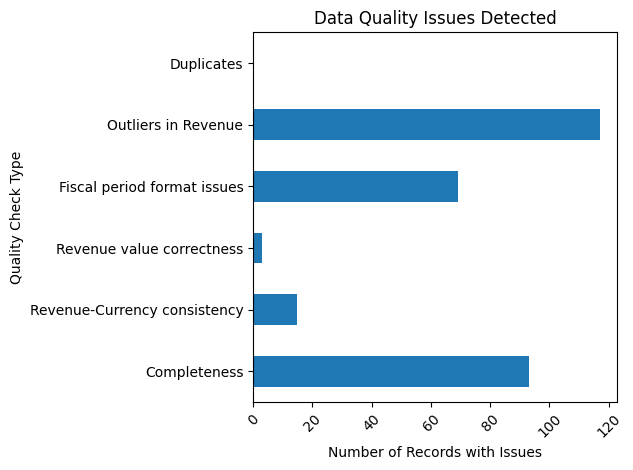

In [22]:
import matplotlib.pyplot as plt

plt.figure()

summary_df["Issue Count"].plot(kind="barh")

plt.title("Data Quality Issues Detected")
plt.ylabel("Quality Check Type")
plt.xlabel("Number of Records with Issues")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("quality_issues.png", dpi=150, bbox_inches="tight")  
plt.show()

## 10. Export Final Output

Save the full dataframe with all flag columns to Excel.

In [23]:
df.to_excel("casestudy_quality_checked_output.xlsx", index=False)